# Airline Passenger Satisfaction Analysis

This project analyzes airline passenger data to identify key factors affecting customer satisfaction. The dataset was cleaned, outliers were treated, and exploratory data analysis was performed. Multiple machine learning models—Logistic Regression, Random Forest, and XGBoost—were implemented and compared.


In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [2]:
#Loading the Dataset
df=pd.read_csv('/content/sample_data/Data.csv')

In [3]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [4]:
# In order to visible all the columns
pd.set_option('display.max_columns',None)
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


In [5]:
df.shape

(129880, 24)

In [6]:
# Checking Duplicates
print(df.duplicated().value_counts())
df.drop_duplicates(inplace = True)
print(len(df))

False    129880
Name: count, dtype: int64
129880


In [7]:
df['Satisfaction'].value_counts()

,count
Satisfaction,
Neutral or Dissatisfied,73452
Satisfied,56428


In [8]:
df.isnull().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,393
Departure and Arrival Time Convenience,0


In [9]:
df.dropna(subset=['Arrival Delay'], inplace=True)
df.isnull().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,0
Departure and Arrival Time Convenience,0


In [10]:
df.describe()

,ID,Age,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000
mean,64958.335169,39.428761,14.643385,15.091129,3.057349,2.756786,3.306239,3.252720,2.976909,3.383204,3.441589,3.351078,3.286222,3.204685,3.642373,2.728544,3.358067,3.631886
std,37489.781165,15.117597,37.932867,38.465650,1.526787,1.401662,1.266146,1.350651,1.278506,1.287032,1.319168,1.316132,1.313624,1.329905,1.176614,1.329235,1.334149,1.180082
min,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32494.500000,27.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64972.000000,40.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97415.500000,51.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129487 non-null  int64  
 1   Gender                                  129487 non-null  object 
 2   Age                                     129487 non-null  int64  
 3   Customer Type                           129487 non-null  object 
 4   Type of Travel                          129487 non-null  object 
 5   Class                                   129487 non-null  object 
 6   Flight Distance                         129487 non-null  object 
 7   Departure Delay                         129487 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129487 non-null  int64  
 10  Ease of Online Booking                  129487 no

In [12]:
 #Drop rows where satisfaction ratings are '0' (if 0 means 'not applicable')
cols_to_clean = ['Departure and Arrival Time Convenience', 'Ease of Online Booking',
                 'Check-in Service', 'Online Boarding', 'Gate Location','On-board Service',
                 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
                 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
                 'In-flight Entertainment', 'Baggage Handling']

for col in cols_to_clean:
    df = df[df[col] != 0]

df.dropna(inplace=True)

In [13]:
df['Satisfaction'].value_counts()

,count
Satisfaction,
Neutral or Dissatisfied,68330
Satisfied,50874


In [14]:
# Dropping ID column
df.drop('ID', axis=1, inplace=True)

In [15]:
df.head()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


In [16]:
# CHECKING UNIQUE VALUES IN CATEGORICAL COLUMN USING FOR LOOP
for column in df.columns:
    if df[column].dtype == object:
        print(str(column)+' : ' +str(df[column].unique()))
        print(df[column].value_counts())
        print("------------------------------------------")

Gender : ['Male' 'Female']
Gender
Female    60416
Male      58788
Name: count, dtype: int64
------------------------------------------
Customer Type : ['First-time' 'Returning']
Customer Type
Returning     100024
First-time     19180
Name: count, dtype: int64
------------------------------------------
Type of Travel : ['Business' 'Personal']
Type of Travel
Business    82445
Personal    36759
Name: count, dtype: int64
------------------------------------------
Class : ['Business' 'Economy' 'Economy Plus']
Class
Business        57992
Economy         52459
Economy Plus     8753
Name: count, dtype: int64
------------------------------------------
Flight Distance : ['821' '853' '1905' ... 1051 1376 1225]
Flight Distance
337     749
2475    440
447     395
236     363
404     356
       ... 
428       1
1956      1
914       1
1459      1
3368      1
Name: count, Length: 6805, dtype: int64
------------------------------------------
Satisfaction : ['Neutral or Dissatisfied' 'Satisfied']
Satis

In [17]:
# Remove non-numeric characters (e.g., '$' and commas if any)
df['Flight Distance'] = df['Flight Distance'].replace('[\$,]', '', regex=True)

# Convert to float
df['Flight Distance'] = pd.to_numeric(df['Flight Distance'], errors='coerce')

# Check the conversion
print(df['Flight Distance'].head())

0     821.0
1     821.0
2     853.0
3    1905.0
4    3470.0
Name: Flight Distance, dtype: float64


In [18]:
df['Flight Distance'].isnull().mean() * 100

df.dropna(subset=['Flight Distance'], inplace=True)
df['Flight Distance'].isnull().mean() * 100

np.float64(0.0)

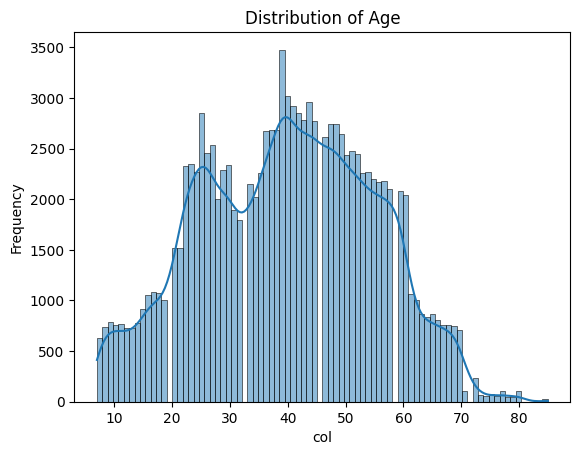

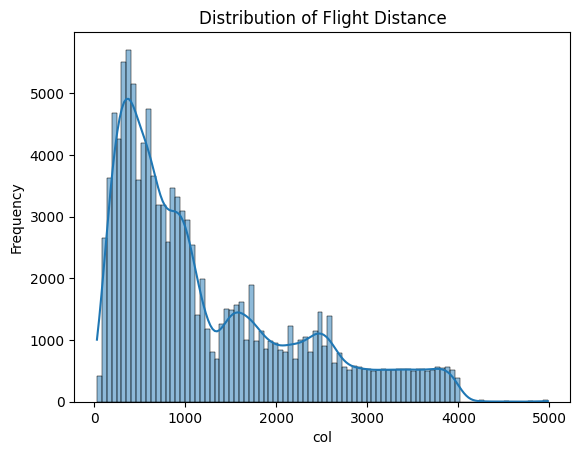

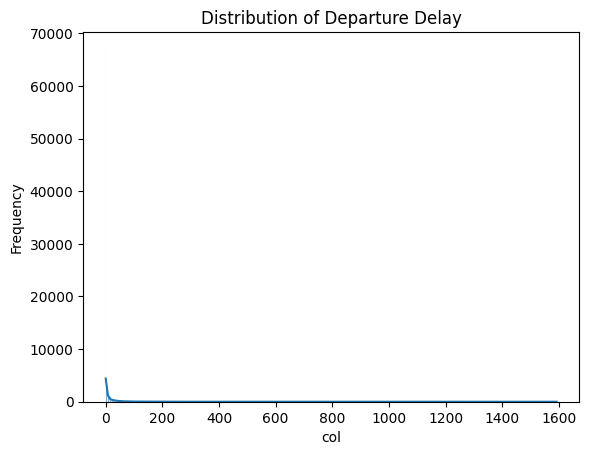

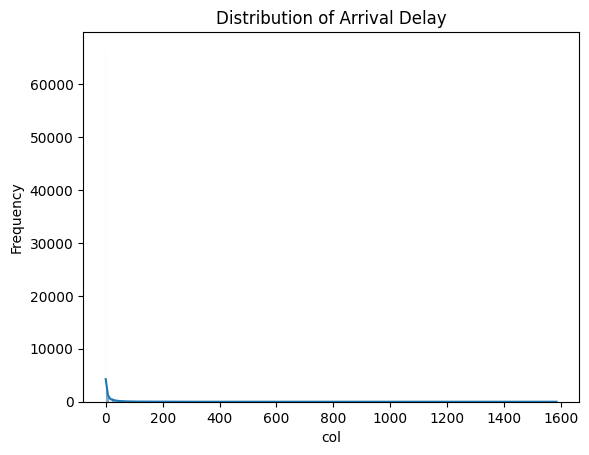

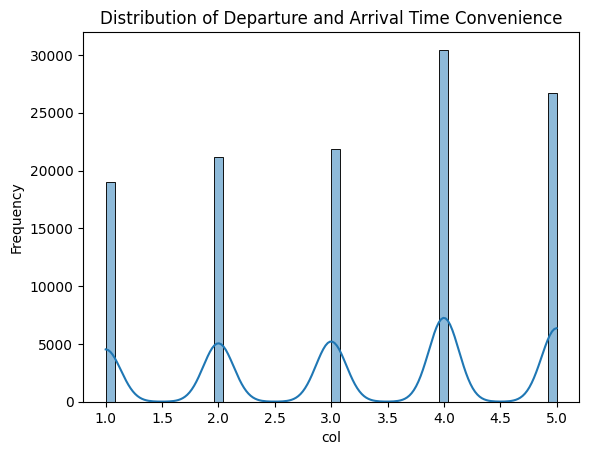

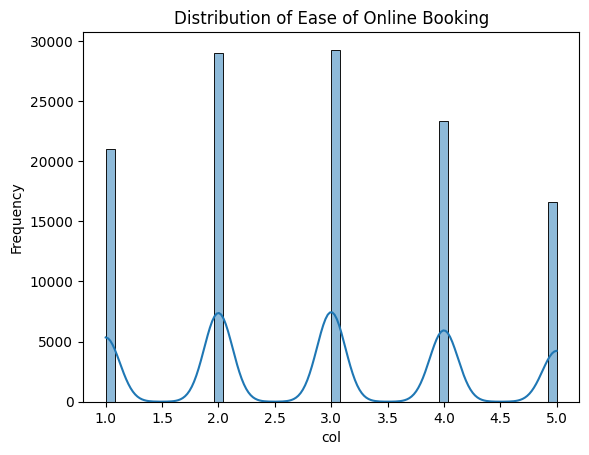

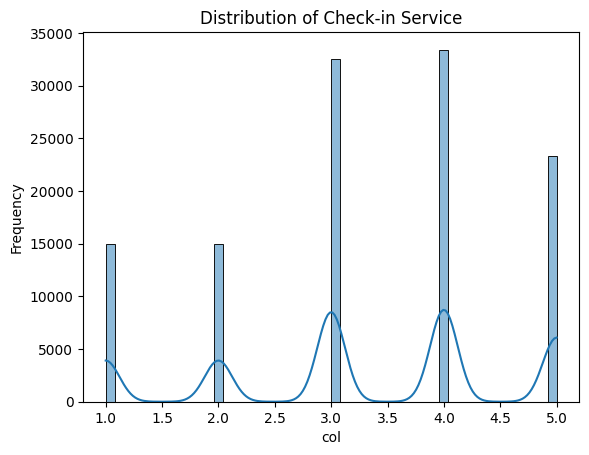

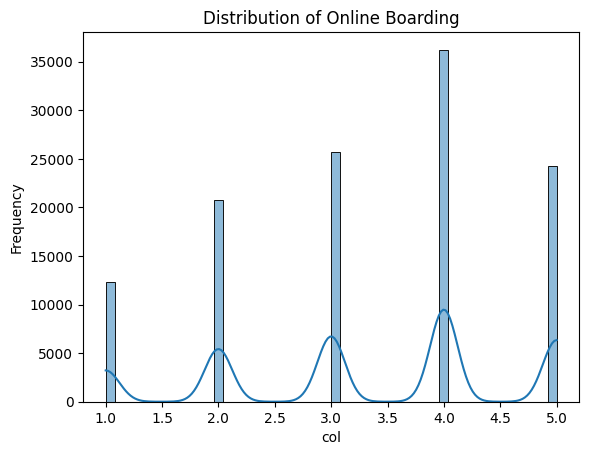

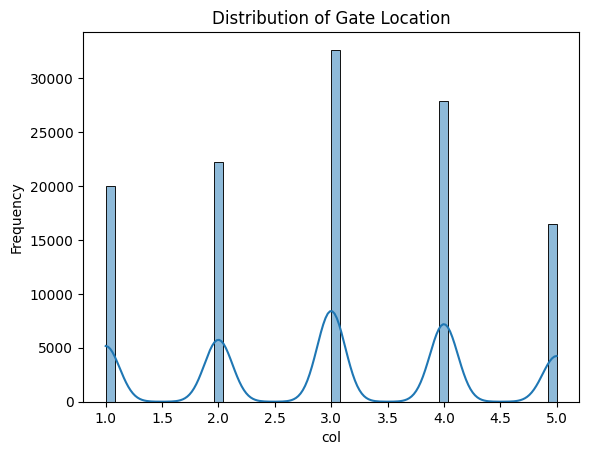

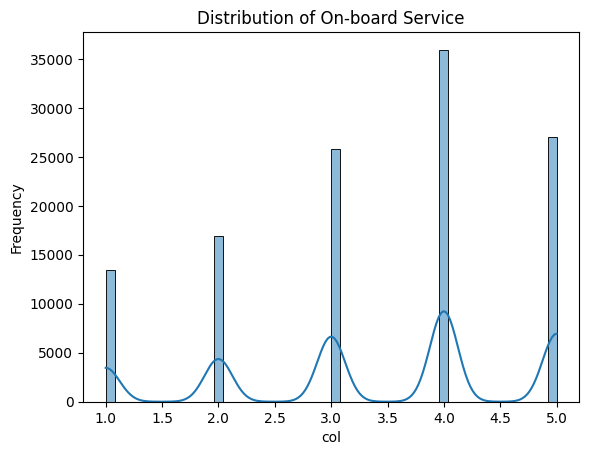

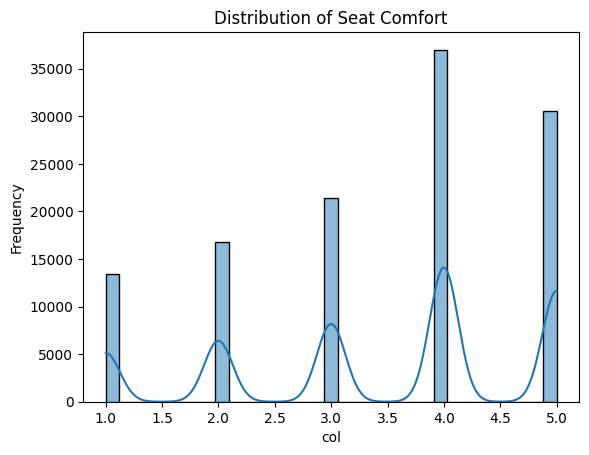

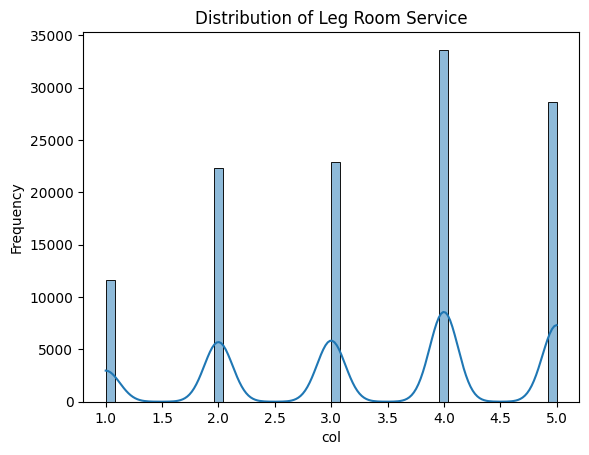

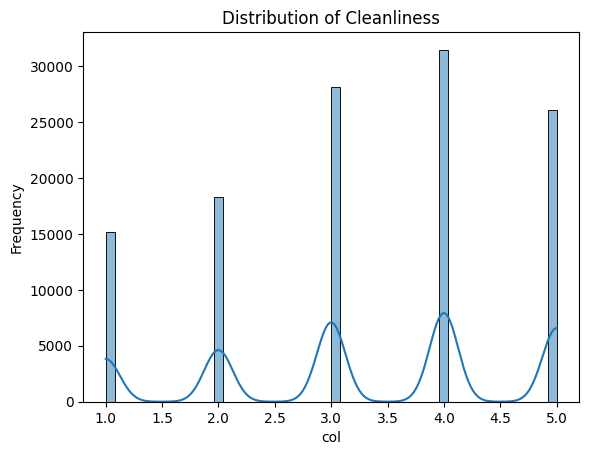

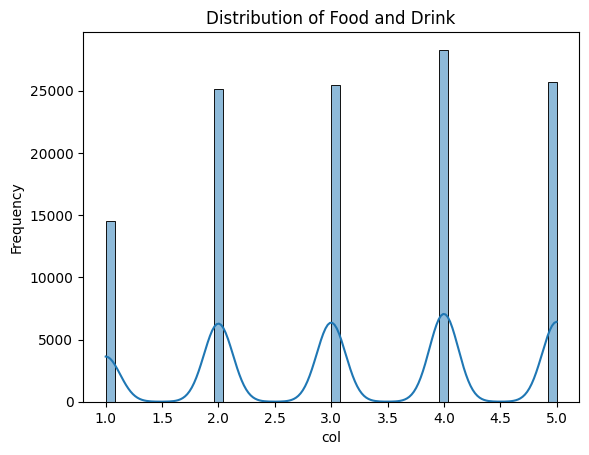

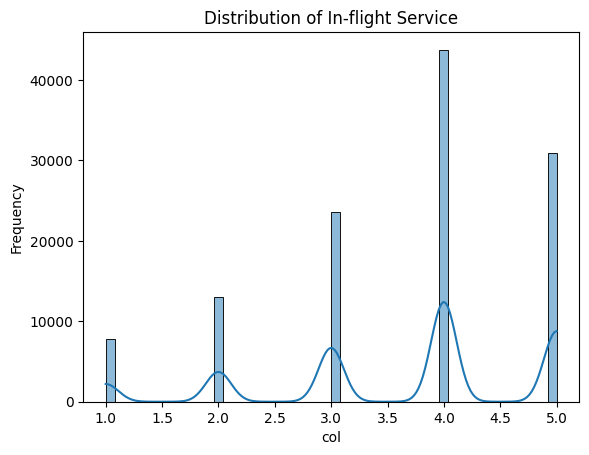

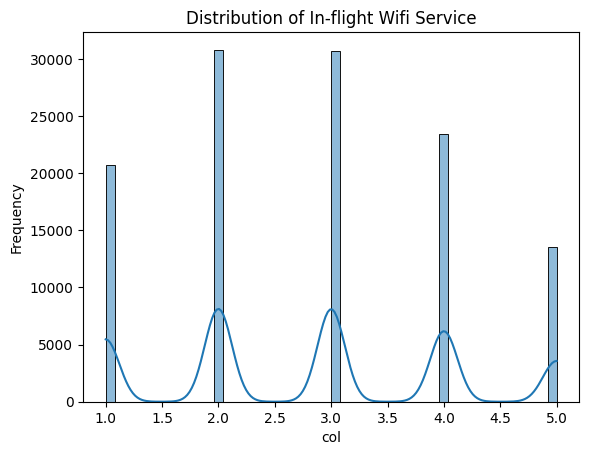

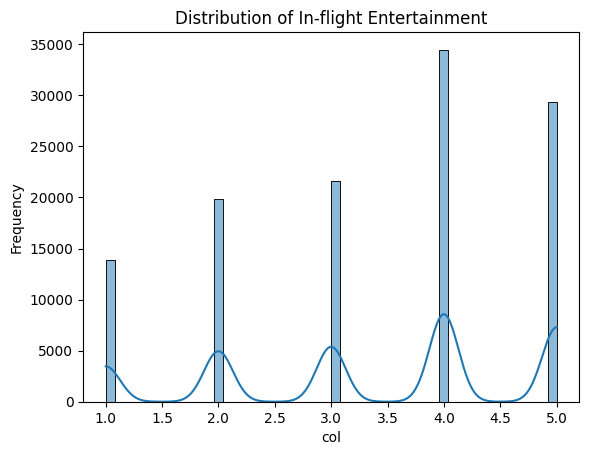

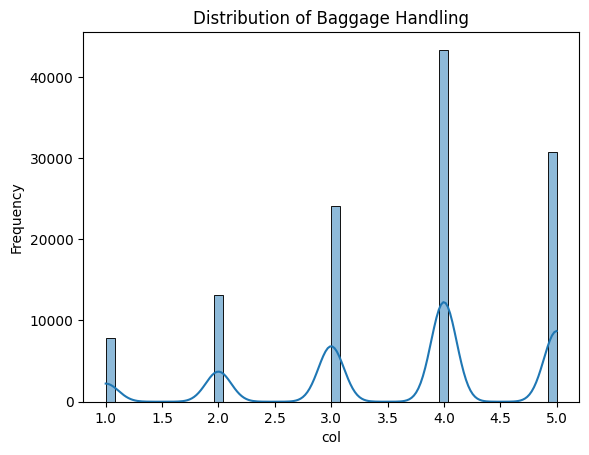

In [19]:

# Define distplot function to visualize distributions
def distplots(col):
    if df[col].dtype != object:  # check if the column is numeric
        sns.histplot(df[col], kde=True)
        plt.xlabel('col')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of {col}')
        plt.show()

for col in df.columns:
    distplots(col)

In [20]:
df.head()

,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,Male,48,First-time,Business,Business,821.0,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821.0,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,Male,41,Returning,Business,Business,853.0,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,Male,50,Returning,Business,Business,1905.0,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,Female,49,Returning,Business,Business,3470.0,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


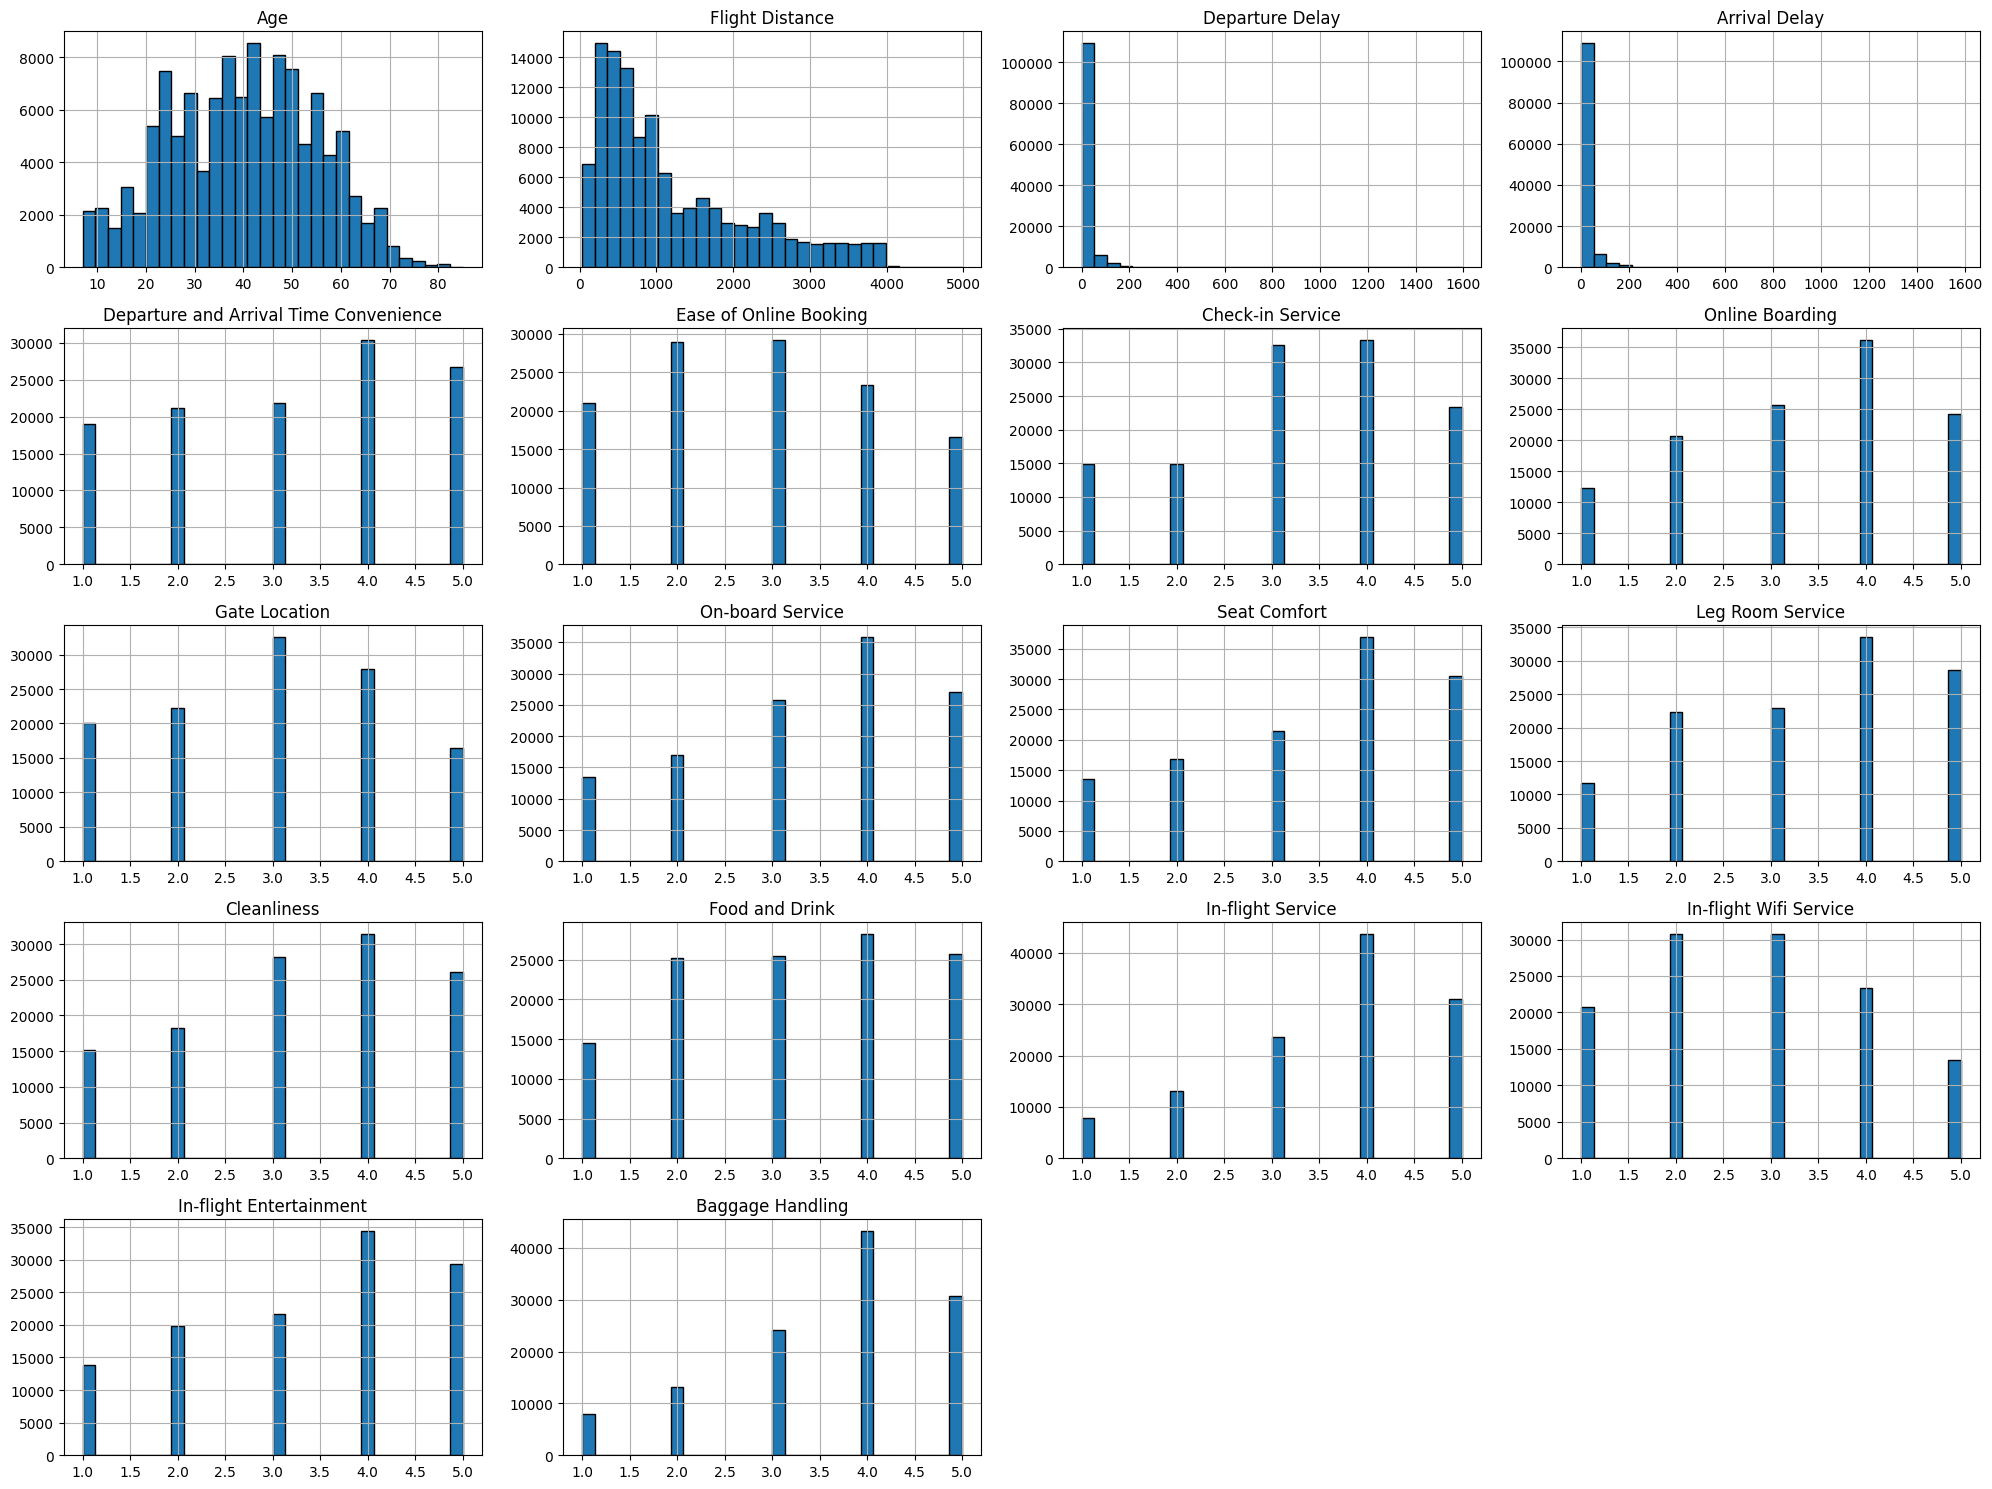

In [21]:
# Plot histograms for all numeric columns
df.hist(figsize=(20, 15), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

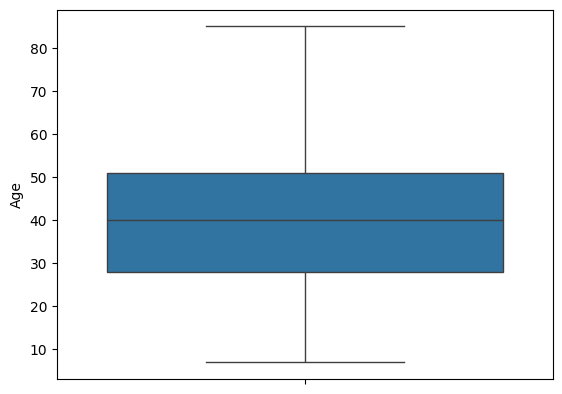

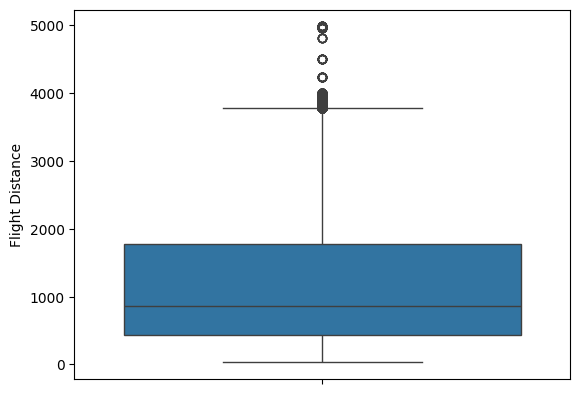

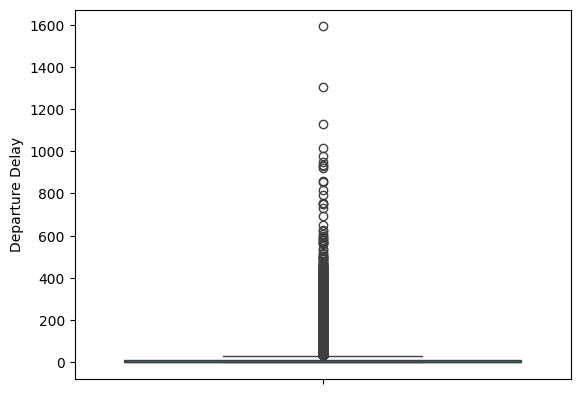

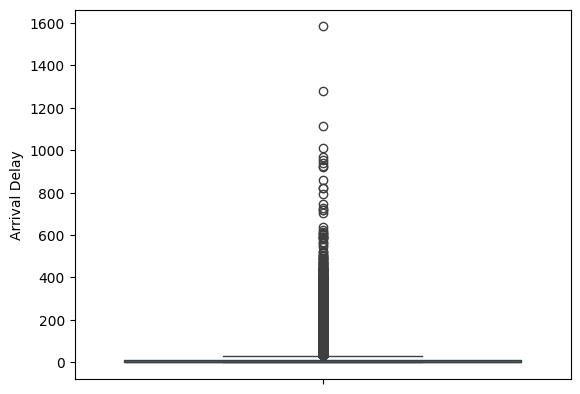

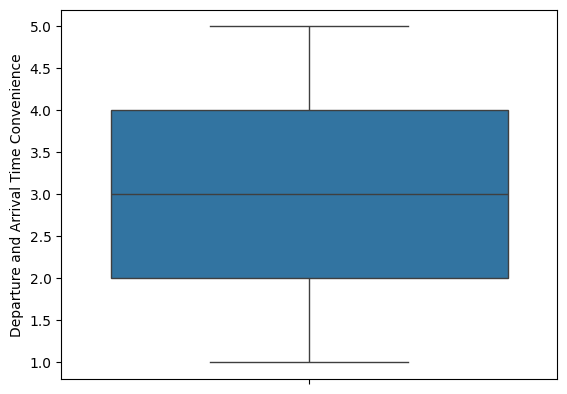

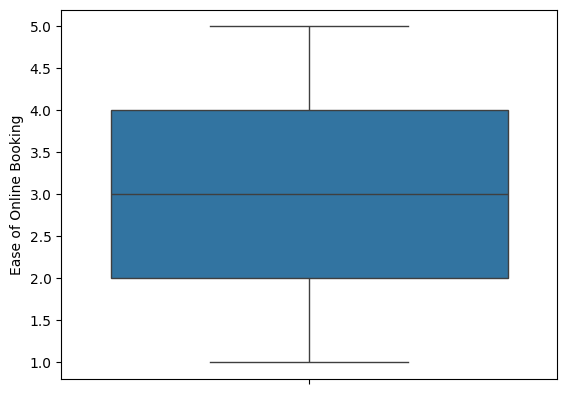

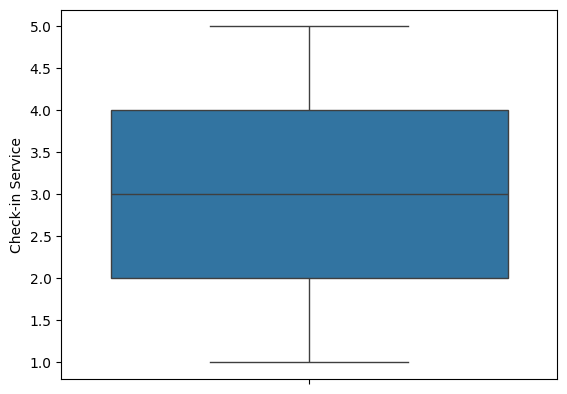

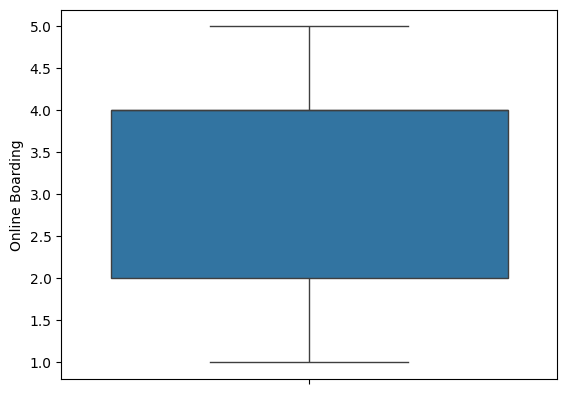

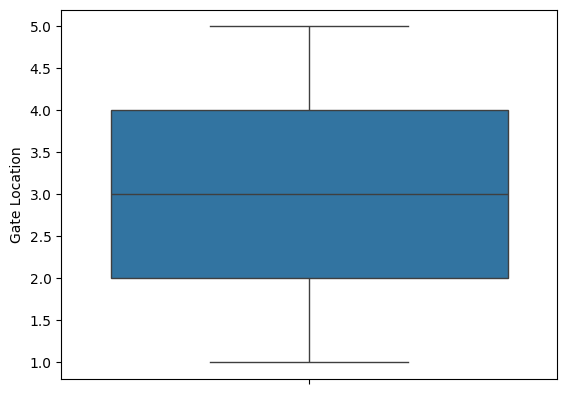

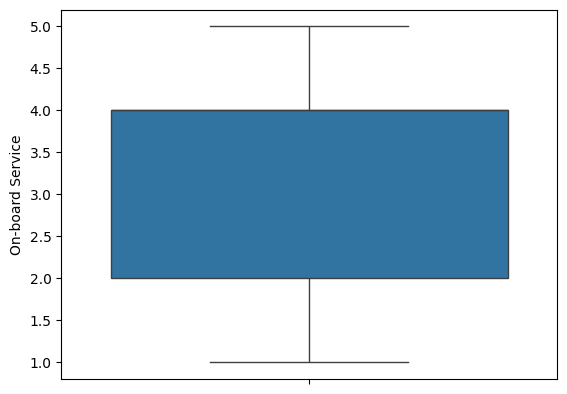

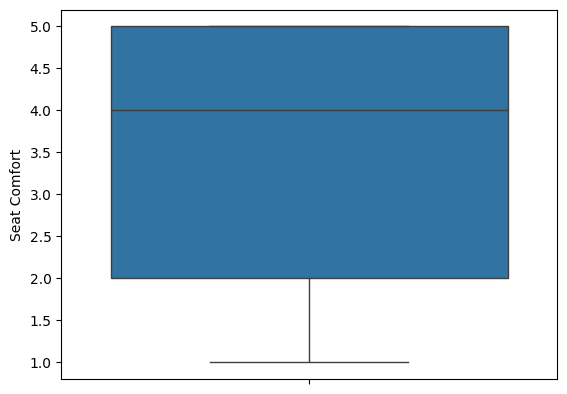

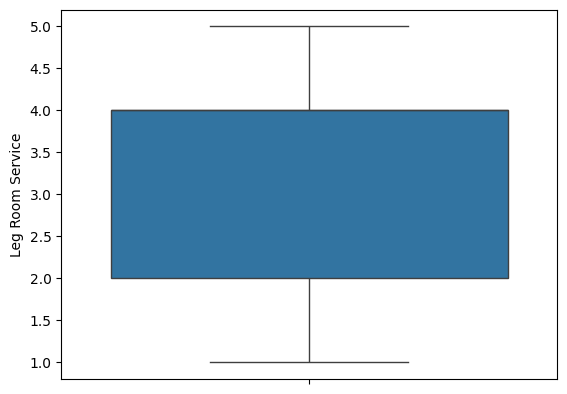

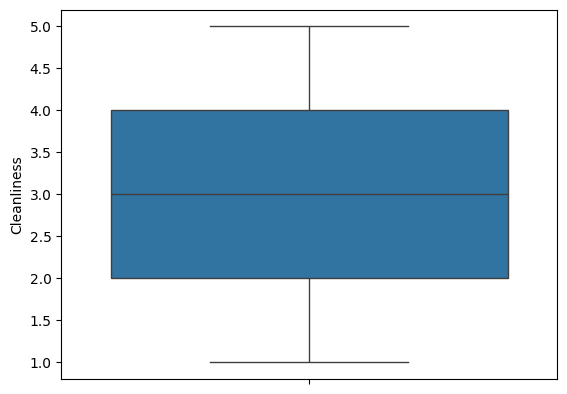

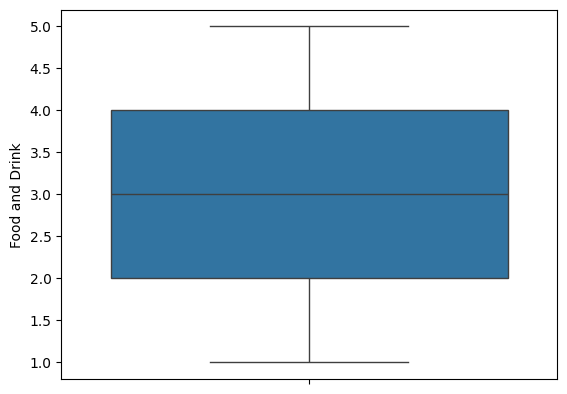

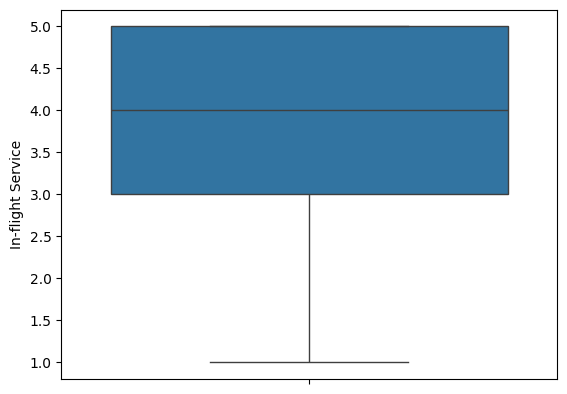

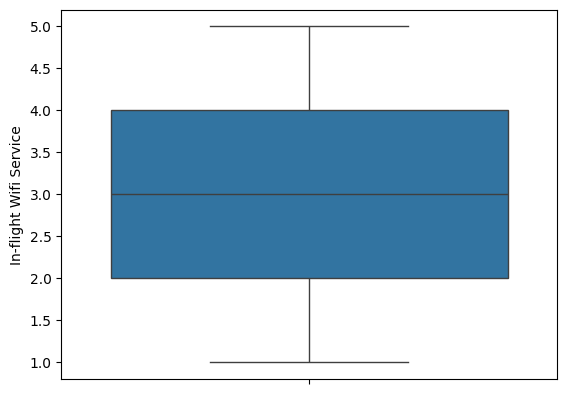

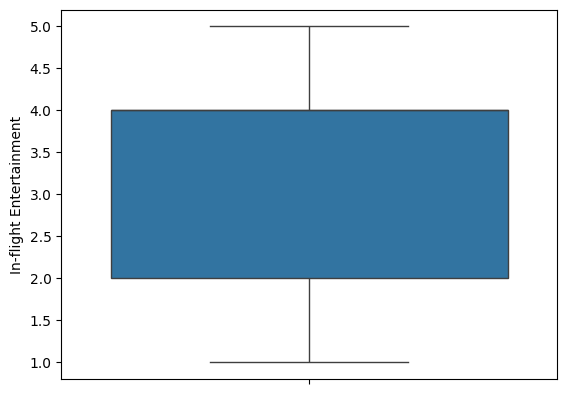

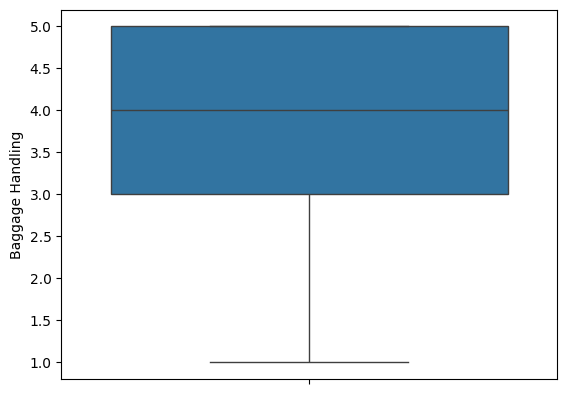

In [22]:

def boxplots(col):
    sns.boxplot(df[col])
    plt.show()

for i in list(df.select_dtypes(exclude=['object']).columns):
    boxplots(i)

In [23]:

# Label Encoding for target column
le = LabelEncoder()
df['Satisfaction'] = le.fit_transform(df['Satisfaction'])  # Satisfied=1, Neutral/Unhappy=0

#  One-hot encoding for other categorical features
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert any boolean columns to integer (0/1)
df = df.astype(int)

In [24]:
df.head()

,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus
0,48,821,2,5,3,3,4,3,3,3,5,2,5,5,5,3,5,5,0,1,0,0,0,0
1,35,821,26,39,2,2,3,5,2,5,4,5,5,3,5,2,5,5,1,0,1,0,0,0
2,41,853,0,0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,1,1,1,0,0,0
3,50,1905,0,0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,1,1,1,0,0,0
4,49,3470,0,1,3,3,3,5,3,3,4,4,5,4,3,3,3,3,1,0,1,0,0,0


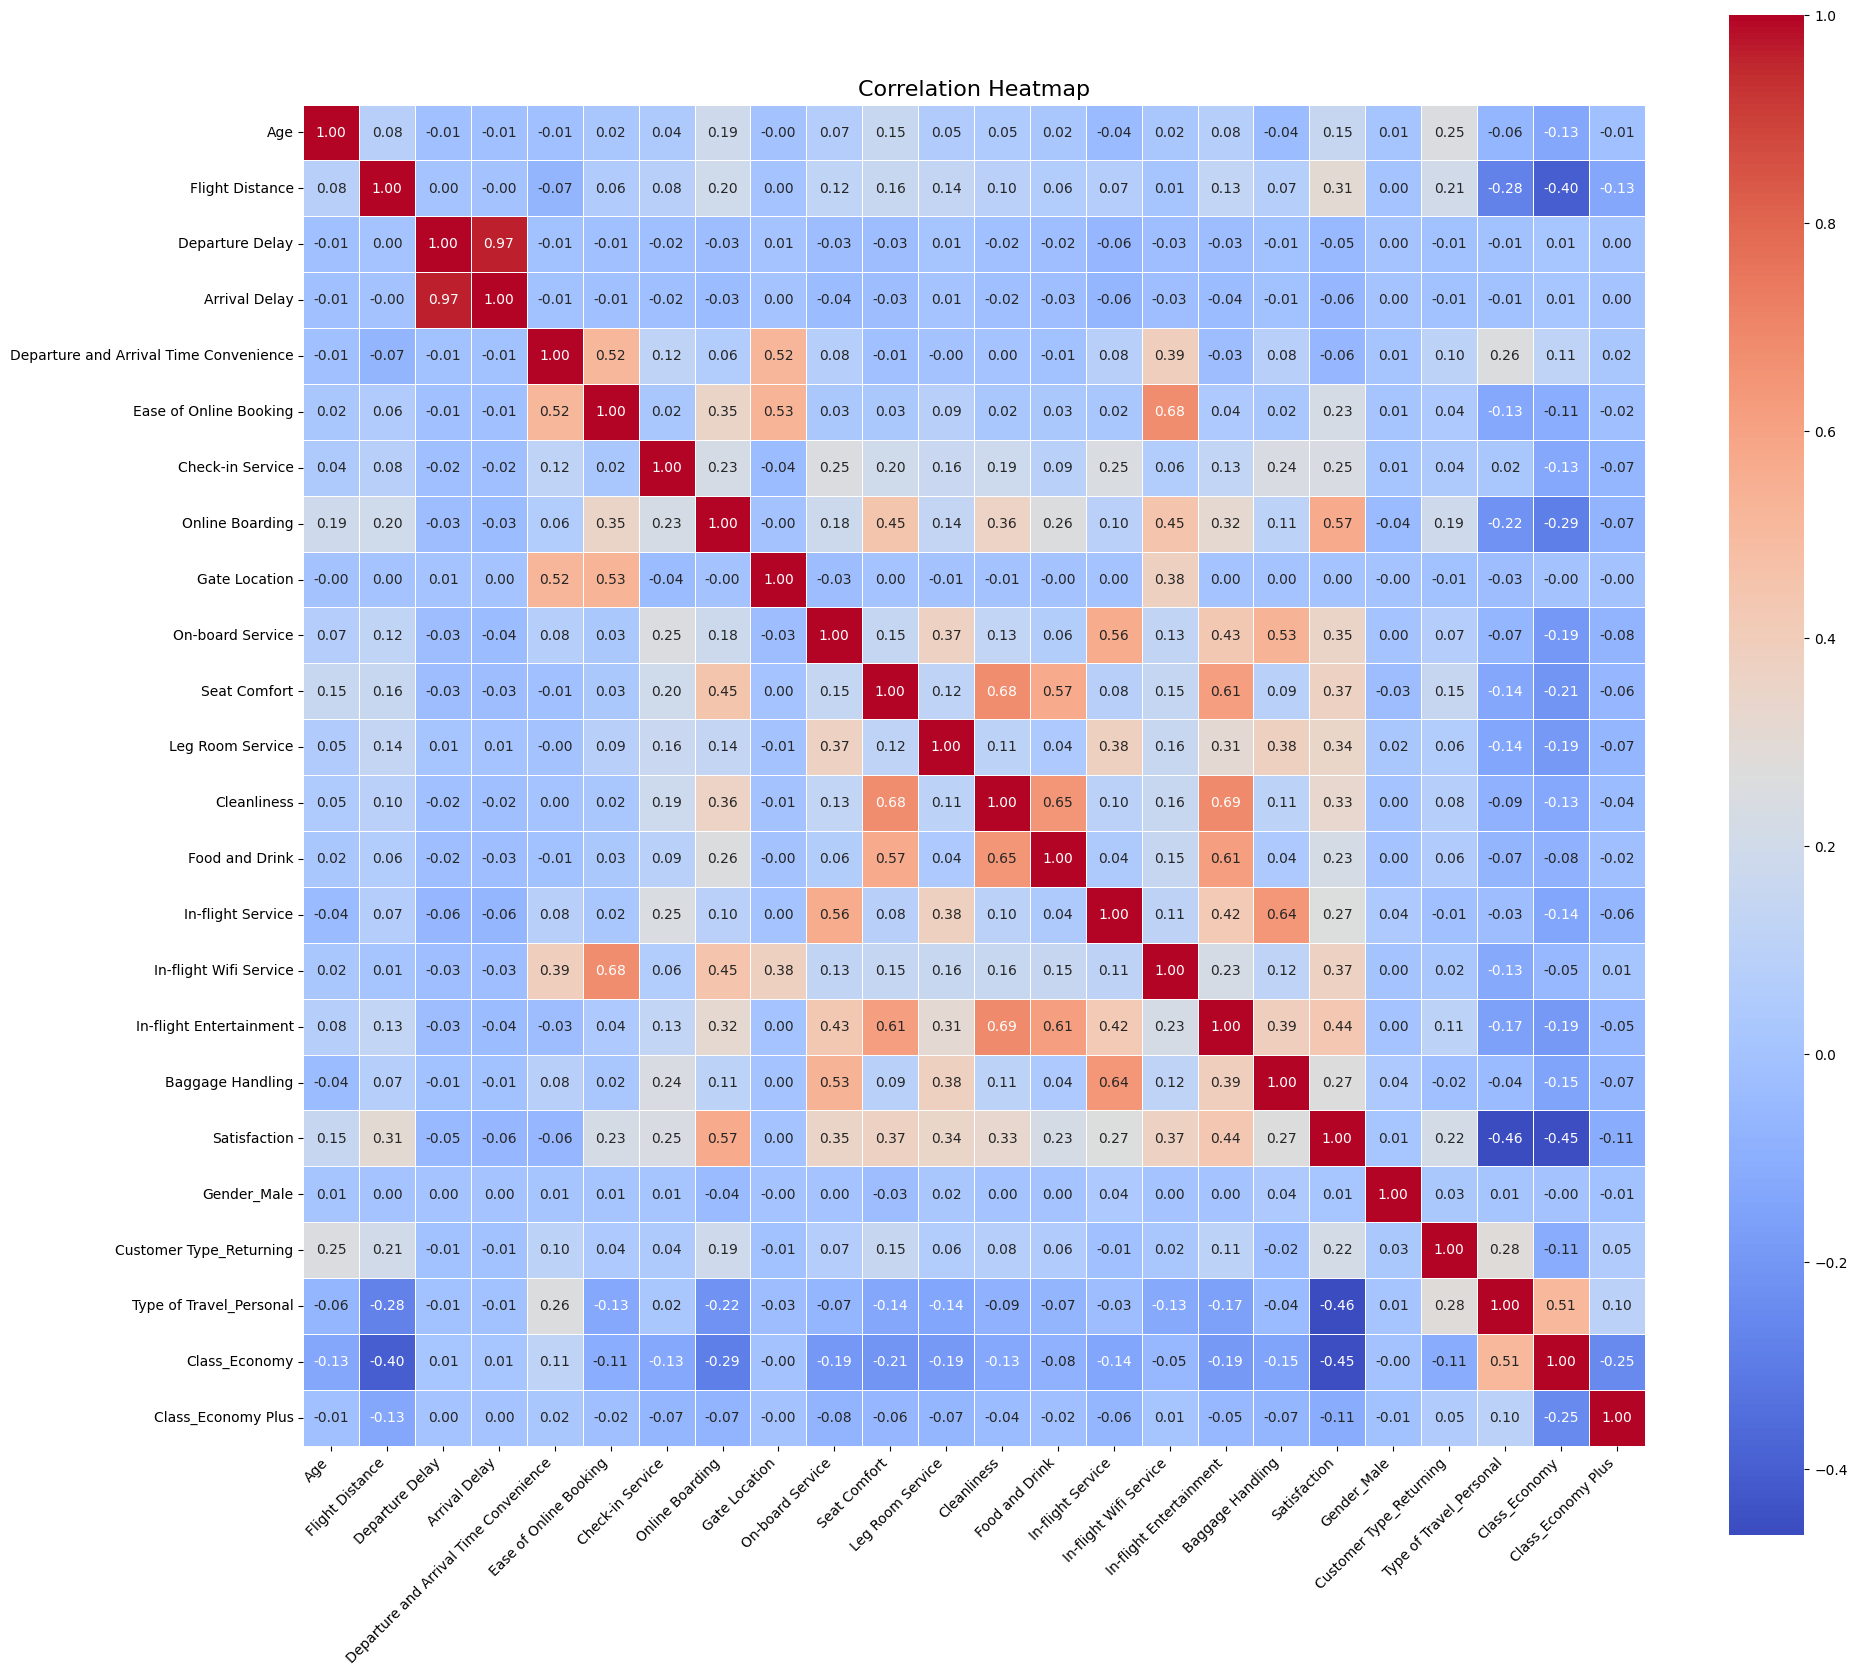

In [25]:
# Visualise the correlation
# Set figure size based on number of features
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True, fmt='.2f',cmap='coolwarm',
            square=True,
            cbar_kws={"shrink": .8},
            linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Drop the 'Arrival Delay' column
#Arrival Delay and Departure Delay is 0.97, which is significantly higher than the typical threshold and indicates strong multicollinearity
df.drop(columns=['Arrival Delay'], inplace=True)

In [27]:
# Outlier Treatment using IQR
# ----------------------
def remove_outliers_iqr(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return data

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('Satisfaction')  # exclude target

df = remove_outliers_iqr(df, numeric_cols)

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (62762, 23)


In [28]:
# Train-Test Split

X = df.drop('Satisfaction', axis=1)
y = df['Satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
X

,Age,Flight Distance,Departure Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus
1,35,821,26,2,2,3,5,2,5,4,5,5,3,5,2,5,5,0,1,0,0,0
2,41,853,0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,1,1,0,0,0
3,50,1905,0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,1,1,0,0,0
4,49,3470,0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,0,1,0,0,0
6,43,1963,0,3,3,4,4,3,5,5,5,4,5,5,3,5,5,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129851,43,337,0,5,3,5,3,4,4,2,2,2,2,3,3,2,2,1,1,1,1,0
129860,30,337,0,2,2,4,5,2,3,5,4,5,5,4,2,5,5,0,1,0,0,0
129862,51,308,0,4,4,4,5,4,5,5,5,4,3,5,4,5,5,1,1,0,0,0
129863,39,2747,0,1,5,3,4,1,5,4,5,3,3,5,1,5,5,0,1,0,0,0


In [30]:
y

,Satisfaction
1,1
2,1
3,1
4,1
6,1
...,...
129851,0
129860,1
129862,1
129863,1


In [31]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Training-Logistic Regression

In [32]:
#  Model Training-Logistic Regression with GridSearchCV

param_grid_lr = {
   'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs','liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

print("Best Logistic Regression Parameters:", grid_lr.best_params_)
print("Test Accuracy:", best_lr.score(X_test_scaled, y_test))
print("Train Accuracy:", best_lr.score(X_train_scaled, y_train))



Best Logistic Regression Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Test Accuracy: 0.9100613399187445
Train Accuracy: 0.9105738015096895



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5531
           1       0.92      0.92      0.92      7022

    accuracy                           0.91     12553
   macro avg       0.91      0.91      0.91     12553
weighted avg       0.91      0.91      0.91     12553



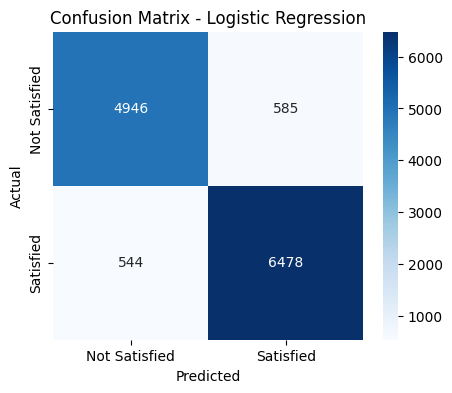

In [33]:
# Predict and evaluate
y_pred_lr = best_lr.predict(X_test_scaled)
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)


# Plot with seaborn heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Satisfied", "Satisfied"],
            yticklabels=["Not Satisfied", "Satisfied"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Model Training-Random Forest

In [38]:
# Random Forest with GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42,oob_score=True,bootstrap=True), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("Best Random Forest Parameters:", grid_rf.best_params_)
print(" OOB Score:", best_rf.oob_score_)   # Train accuracy
print(" OOB Error Rate:", 1 - best_rf.oob_score_)
print(" Test Accuracy:", best_rf.score(X_test, y_test))



Best Random Forest Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
 OOB Score: 0.969168874106236
 OOB Error Rate: 0.030831125893764022
 Test Accuracy: 0.9717995698239464



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      5531
           1       0.99      0.96      0.97      7022

    accuracy                           0.97     12553
   macro avg       0.97      0.97      0.97     12553
weighted avg       0.97      0.97      0.97     12553



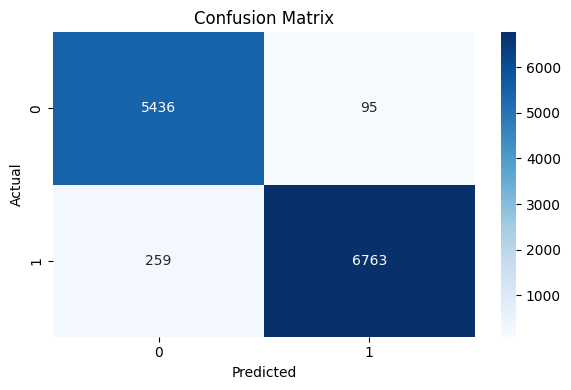

In [39]:
# Predict and evaluate
y_pred_rf = best_rf.predict(X_test)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot confusion matrix as heatmap
cm=confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [40]:
# Model training with xg-boost
# Define parameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Create the model and run GridSearchCV
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_xgb = GridSearchCV(xgb_clf, param_grid_xgb, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
grid_xgb.fit(X_train, y_train)

# Best model
best_xgb = grid_xgb.best_estimator_
print("Best Parameters:", grid_xgb.best_params_)
print(" Test Accuracy:", best_xgb.score(X_test, y_test))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1}
 Test Accuracy: 0.9721182187524895


In [37]:
print(" Test Accuracy:", best_xgb.score(X_test, y_test))
print(" Train Accuracy:", best_xgb.score(X_train, y_train))

 Test Accuracy: 0.9721182187524895
 Train Accuracy: 0.9817164253420702



Classification Report - Tuned XGBoost:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5531
           1       0.99      0.96      0.97      7022

    accuracy                           0.97     12553
   macro avg       0.97      0.97      0.97     12553
weighted avg       0.97      0.97      0.97     12553



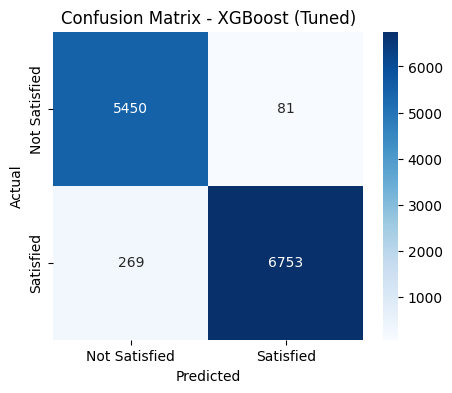

In [35]:
# Evaluation
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\nClassification Report - Tuned XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Satisfied", "Satisfied"],
            yticklabels=["Not Satisfied", "Satisfied"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.show()


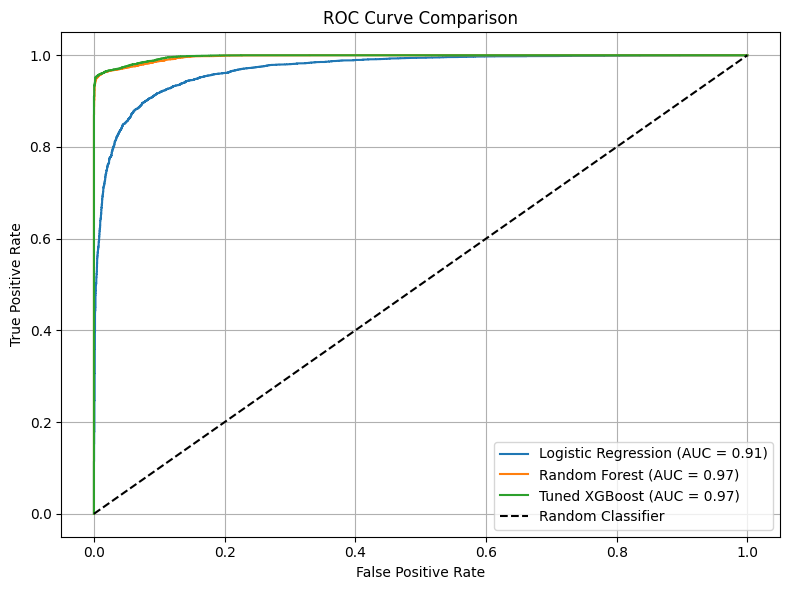

In [41]:
# --- Calculate ROC and AUC for each model ---

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, best_lr.predict_proba(X_test_scaled)[:, 1])
auc_lr = roc_auc_score(y_test, y_pred_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
auc_rf = roc_auc_score(y_test, y_pred_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)  # y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)

# --- Plot all ROC curves together ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = {:.2f})'.format(auc_lr))
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = {:.2f})'.format(auc_rf))
plt.plot(fpr_xgb, tpr_xgb, label='Tuned XGBoost (AUC = {:.2f})'.format(auc_xgb))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Plot settings
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

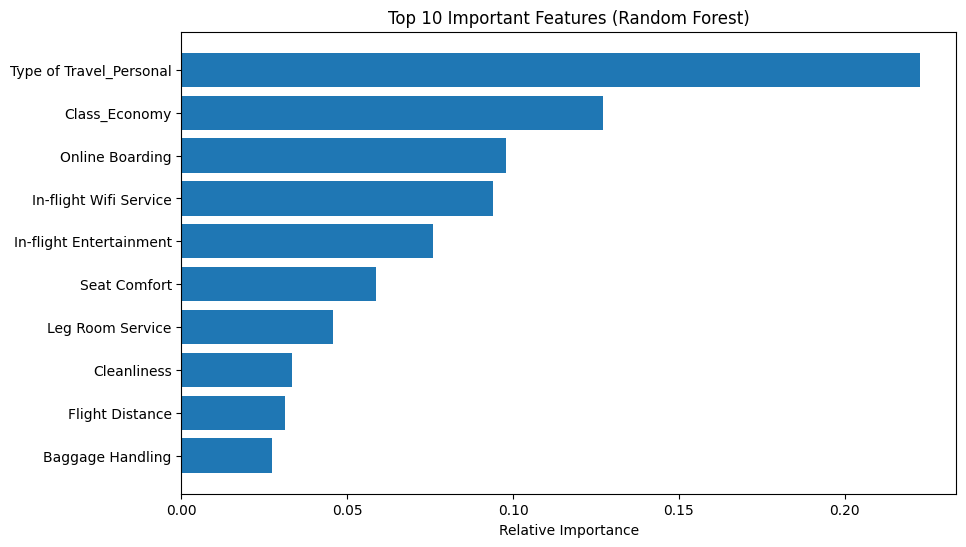

In [42]:
# Feature Importance (Random Forest)

importances = best_rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Important Features (Random Forest)")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

 CONCLUSION:
 XGBoost proved to be the most accurate, followed closely by Random Forest, while Logistic Regression showed competitive results. These models offer valuable tools for improving customer satisfaction prediction in the airline industry.